# **Project Name:-** E-Commerce Sales Analysis

#### Project Type:- ***Data Validation, Data Cleaning, Data Analytics, PowerBI Dashboard***
#### Contribution:- ***Individual***

# **Project Summary**

The data in this project represents historical sales data of an e-commerce company. It was collected to help management understand ***Sales Performance***, ***Customer Purchasing Behaviour***, & ***Regional Trends***.

The main purpose of this project is to ***support data insights*** & ***generate insights*** for improving business strategies & increasing profitability.

# **Problem Statement**

#### *1. How is the sales performance?*
#### *2. What are the regional trends?*
#### *3. Which Products are more profitable?*

# **Business Objectives**

#### *1. Understanding Csutomer purchasing behaviour.*
#### *2. Generate insights for improving business strategies & increasing profit.*
#### *3. Identifying key business risk areas.*

# 1. Know your data

### **Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

### **Dataset Loading**

In [2]:
df = pd.read_csv("ecommerce_sales_data.csv")

### **Dataset First View**

In [3]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


### **Dataset: Rows & Column count**

In [4]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 3500
Number of Columns: 7


### **Dataset Info**

**Dupliacte Values**

In [5]:
df.duplicated().sum()

np.int64(0)

**Missing Values**

In [6]:
def missing_count(df):
    missing_vals = df.isnull().sum()
    data_len = len(df)
    missing_perc = (missing_vals/data_len)*100
    return round(missing_perc,2)

In [7]:
missing_count(df)

Order Date      0.0
Product Name    0.0
Category        0.0
Region          0.0
Quantity        0.0
Sales           0.0
Profit          0.0
dtype: float64

### **What do you know about data**

- The dataset has has total 7 columns with 3500 rows
- There are no duplicates in the dataset.
- There are no missing values in dataset.

# 2. Understanding your variables

### **Dataset columns**

In [8]:
df.columns

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')

### **Dataset Describe**

In [9]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


### **Check unique values for each variable**

In [10]:
def unique_cols(x):
    for col in x.columns:
        print(f"column: {col}")
        print(f"Unique vals: {x[col].nunique()}")
        print(x[col].unique())
        print("*"*40)

In [11]:
unique_cols(df)

column: Order Date
Unique vals: 1051
['2024-12-31' '2022-11-27' '2022-05-11' ... '2022-09-20' '2023-10-06'
 '2022-04-12']
****************************************
column: Product Name
Unique vals: 10
['Printer' 'Mouse' 'Tablet' 'Camera' 'Headphones' 'Smartwatch' 'Monitor'
 'Smartphone' 'Keyboard' 'Laptop']
****************************************
column: Category
Unique vals: 3
['Office' 'Accessories' 'Electronics']
****************************************
column: Region
Unique vals: 4
['North' 'East' 'South' 'West']
****************************************
column: Quantity
Unique vals: 9
[4 7 5 2 1 9 8 6 3]
****************************************
column: Sales
Unique vals: 2377
[3640 1197 5865 ... 5888 1022 1117]
****************************************
column: Profit
Unique vals: 3447
[ 348.93  106.53  502.73 ...   66.02   50.28 1777.32]
****************************************


# 3. *Data Wrangling*

In [12]:
def cost_cal(x):
    cost = x['Sales'] - x['Profit']
    return cost

In [13]:
df['Total Cost'] = cost_cal(df)

In [14]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Total Cost
0,2024-12-31,Printer,Office,North,4,3640,348.93,3291.07
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,1090.47
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,5362.27
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,583.13
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,405.72


In [15]:
# Output Csv
df.to_csv("Sales.csv")

# 4. *Data Visualization, Story Telling & Experimenting with Charts: Understanding the relationships between variables.*

#### **Chart - 1**

In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date'],format = "%Y-%m-%d")

In [17]:
df['YearMonth'] = df['Order Date'].dt.to_period('M')
df['YearMonth'] = df['YearMonth'].dt.to_timestamp()

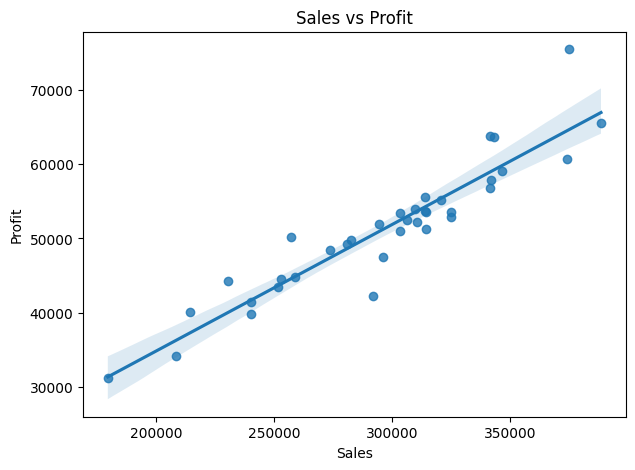

In [18]:
df_temp = df.groupby('YearMonth')[['Sales','Profit']].sum().reset_index()

plt.figure(figsize = (7,5))
sns.regplot(x = 'Sales',y = 'Profit', data = df_temp)
plt.title('Sales vs Profit')
plt.show()

**Purpose of the Chart**

*This chart shows the relationship between monthly sales and profit.* 

**Insights**

*From this chart we can see that the profit is sales and/order volume driven*

**Impact on Business**

*Since the profit is sales driven, the E - Commerce organisation can focus or target high sales for more profit.*

#### **Chart - 2**

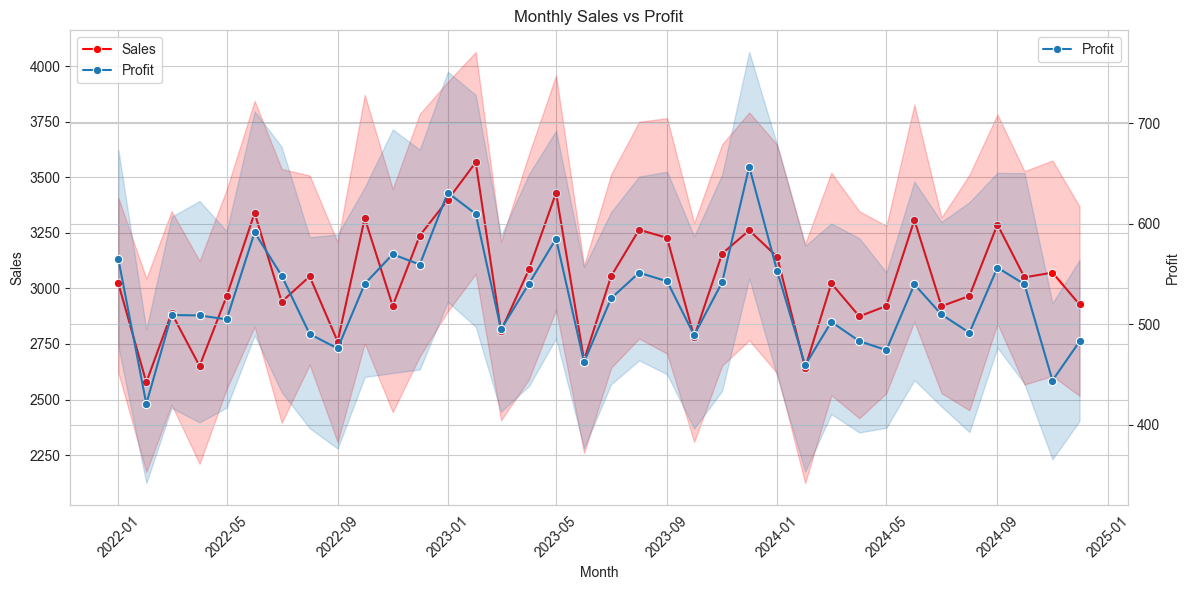

In [19]:
sns.set_style("whitegrid") 

fig, ax1 = plt.subplots(figsize=(12,6))
sns.lineplot(data=df,x='YearMonth',y='Sales',marker='o',ax=ax1,color = "Red",label = 'Sales')

ax1.set_xlabel('Month')
ax1.set_ylabel('Sales')
ax2 = ax1.twinx()

sns.lineplot(data=df,x='YearMonth',y='Profit',marker='o',ax=ax2,label = 'Profit')

ax2.set_ylabel('Profit')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('Monthly Sales vs Profit')
ax1.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Purpose of the chart**

*This line chart show the Sales and profit trend*

**Insights**

- *Sales and profit move closely together, indicating a strong positive correlation.*
- *There is noticeable month-to-month volatility in both metrics.*
- *Overall, there appears to be a gradual upward trend year over year.*
- *Certain months show sharp dips, which may indicate seasonality or operational inefficiencies.*

**Impact on Business**

- *The positive correlation suggests that revenue growth is translating into profitability.*
- *However, high volatility could signal seasonality, demand fluctuations, pricing changes, or operational inefficiencies.*
- *Further investigation into monthly dips is required before concluding root causes such as inventory issues.*

**Chart - 3**

<Axes: xlabel='YearMonth', ylabel='Sales_Rolling_3'>

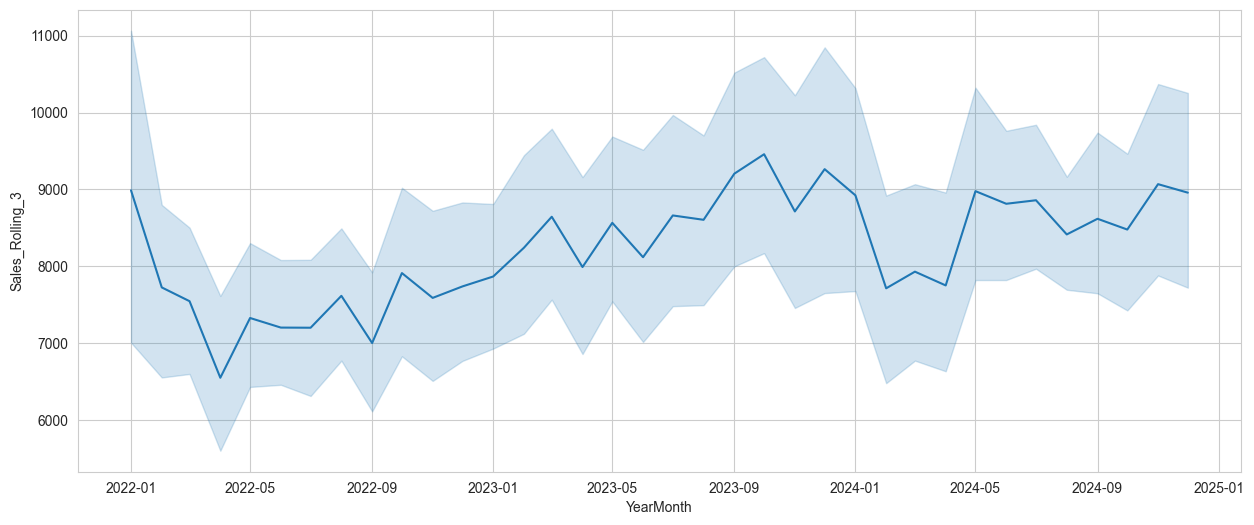

In [20]:
df_temp = df.groupby(
    ['YearMonth','Product Name','Category','Region']
)['Sales'].sum().reset_index()

# Make sure sorted
df_temp = df_temp.sort_values(
    ['Product Name','Category','Region','YearMonth']
)

# Apply rolling per group
df_temp['Sales_Rolling_3'] = (
    df_temp
    .groupby(['Product Name','Category','Region'])['Sales']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

plt.figure(figsize = (15,6))
sns.lineplot(x = 'YearMonth',y = 'Sales_Rolling_3',data = df_temp)

**Purpose of the chart**

*This line chart shows the three month moving avaerage sales trend. This is much less noisy than monthly sales trend chart.*

**Insights**

*1. Overall Trend: Upward Growth*
    - *Sales show a clear upward trend from early 2022 to late 2023.*
    - *The rolling average smooths short-term fluctuations and confirms consistent growth momentum through 2023.*

*2. Early 2022 Dip*
    - *There is a noticeable decline from January to around April 2022.*
    - *After that dip, sales gradually recover and begin trending upward again.*

*3. Strong Performance in Late 2023*
    - *The highest levels appear around Q3–Q4 2023.*
    - *This may indicate seasonal strength (e.g., festive or year-end demand).*

*4. Drop in Early 2024*
- *There is a visible decline around Jan–Feb 2024, suggesting:*
    - *Possible post-season slowdown*
    - *Demand correction*
    - *External business factors*

*5. Recovery After Dip*
- *After the early 2024 drop, sales rebound again.*
    - *The trend stabilizes around \\$8,800 to \\$9,000+, indicating resilience.*

*6. Volatility Band (Shaded Area)*
- *The shaded region suggests variability around the rolling average.*
- *Wider bands in late 2023 imply:*
    - *Higher fluctuations*
    - *Strong but less stable growth during peak months*

**Business Interpretation**

The business is in a growth phase overall.
- There appears to be seasonality, with stronger second-half performance.
- Early-year softness might require:
    - Promotions
    - Marketing push
    - Inventory adjustments

**Chart - 4**

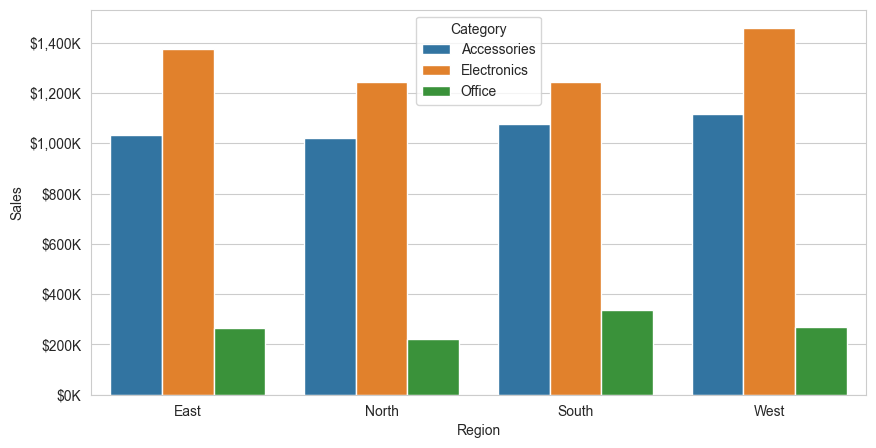

In [21]:
# Sales Per region category wise
df_temp = df.groupby(['Region','Category'])['Sales'].sum().reset_index()
df_temp

plt.figure(figsize = (10,5))
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K')
sns.barplot(df_temp,x = 'Region',y = 'Sales',hue = 'Category')
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

**Purpose of the chart**

*Thsi clustered bar chart shows the Category wise sales across each region.*

**Insights**

- *Electronics has highest sales across all regions. With maximaum sales in West Region ***(> \\$1400K)***.*
- *Office category has lowest sales across all regions, with highest in South region ***(> \\$300K)***.*
- *Revenue is heavily concentrated in two categories (Electronics & Accessories).*
- ***Business Risk***: *If Electronics and Accessories dips, total revenue drops significantly.*

**Business Recommendation**

- *Focaus growth investment in West region (Electronics expansion).*
- *Improve North region performance*
- *Promote office category via bundle offer*

**Chart - 5**

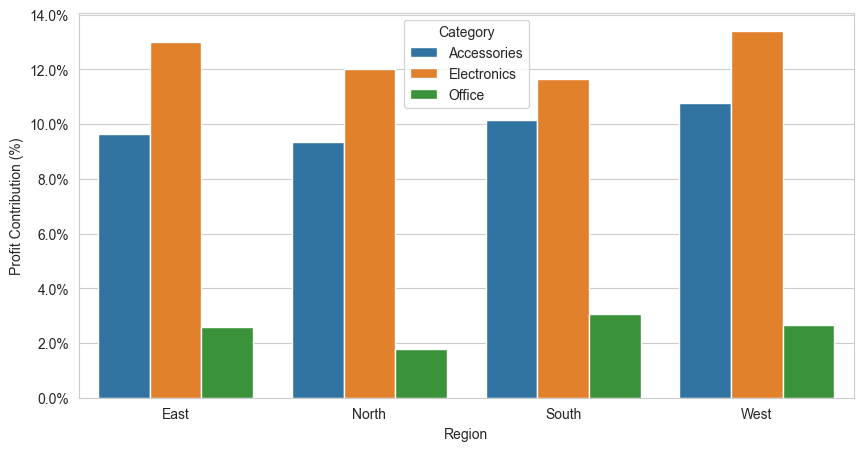

In [22]:
df_temp = df.groupby(['Region','Category'])['Profit'].sum().reset_index()
total_profit = df_temp['Profit'].sum()
df_temp['Profit_contribution'] = (df_temp['Profit']/total_profit)*100

plt.figure(figsize = (10,5))
formatter = ticker.FuncFormatter(lambda x, pos: f'{x}%')
sns.barplot(df_temp,x = 'Region',y = 'Profit_contribution',hue = 'Category')
plt.gca().yaxis.set_major_formatter(formatter)
plt.ylabel("Profit Contribution (%)")
plt.show()

**Purpose of the Chart**

*This chart shows the Profit contribution by categories across all regions*

**Insights**

- *Electronics category is high performing category across all regions, with maximum in West region (profit contribution > 13%).*
- *Office category has lowest profit contribution across all region, with lowest being in North region (< 2%).*
- *Profit is heavily based on two categories (Electronics & Accessories).*
- ***Business Risk***: *If Profit fro electronics dips, total profit drops ignificantly.*

**Business Recommendation**

- *Focus growth investment in West region (Electronics expansion).*
- *Improve North and South Region performance.*
- *Promote office category via bundle offer.*

**Chart - 5A**

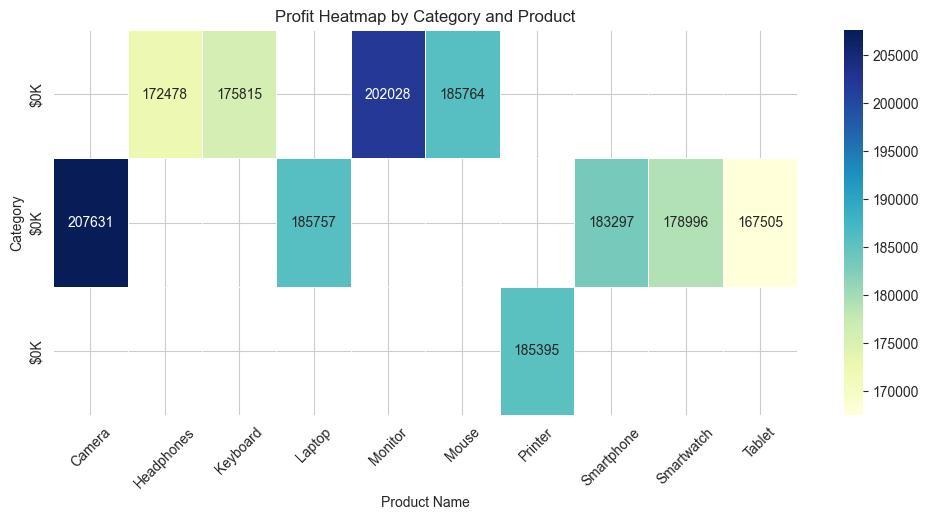

In [23]:
# Number of products in each category.
df_temp = df.groupby(['Category','Product Name'])['Profit'].sum().reset_index()
heatmap_data = df_temp.pivot(index='Category', columns='Product Name', values='Profit')
heatmap_data
plt.figure(figsize=(12,5))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt=".0f", 
            cmap="YlGnBu",
            linewidths=0.5)
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Profit Heatmap by Category and Product")
plt.xticks(rotation=45)
plt.show()

**Purpose of the chart**

*This Heatmap Chart shows the category wise and product wise Profit*

**Insights**

- ***Accessories***
    - *This category has four products (Headphones, Keyboard, Monitor and Mouse).*
    - *Monitor has the highest Profit (\\$202028).*
    - *Headphones have lowest Profit (\\$172478).*
- ***Electronics***
    - *This category has five products (Camera, Laptop, Smartphone, Smartwatch and Tablet).*
    - *Camera has high profits (\\$207631).*
    - *Tablet has lowest Profits (\\$167505).*
- ***Office***
    - *This category has only one product (Printer), whose profits is  \\$185395.*

**Business Strategy**

- ***Accessories***
    - *Headphone could be bundled with tablet sales to make sales of headphone more significant.*
- ***Electronics***
    - *Tablet Sales needs to be boosted by marketing campaigns, advertising.*

**Chart - 6**

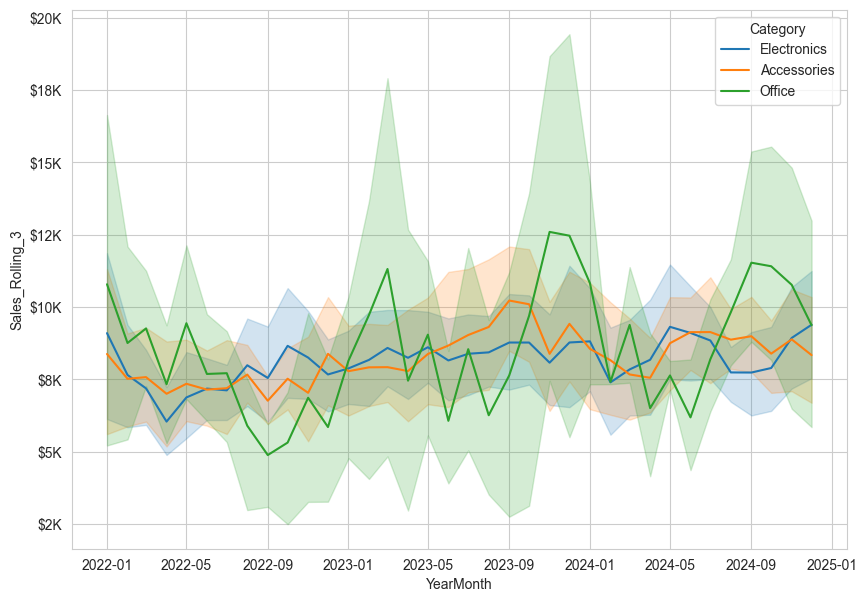

In [24]:
df_temp = df.groupby(
    ['YearMonth','Product Name','Category','Region']
)['Sales'].sum().reset_index()

df_temp = df_temp.sort_values(
    ['Product Name','Category','Region','YearMonth']
)

df_temp['Sales_Rolling_3'] = (
    df_temp
    .groupby(['Product Name','Category','Region'])['Sales']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K')
plt.figure(figsize = (10,7))
sns.lineplot(x = 'YearMonth',y = 'Sales_Rolling_3',data = df_temp,hue = 'Category')
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

**Purpose of the chart**

*This chart shows the category wise sales trend (3 Month moving average).*

**Insights**

1. *The Electronic Sales remained consistent except with some dips in Early 2022 and early 2024.*
2. *The Accessories Sales showed medium consistency with some instability between May-2023 to September-2023, with some dips around Early 2022, on Q3 of 2022 and Q1 of 2024.*
3. *The Office sales is highly unstable with frequent dips and rise.*


**Business Recommendation**

- Revenue stability mainly depends on electronics.
- Office category introduces revenue uncertainity.
- Growth momentum came during mid 2023 to end 2023.
- No long term decline trend.

**Chart - 7**

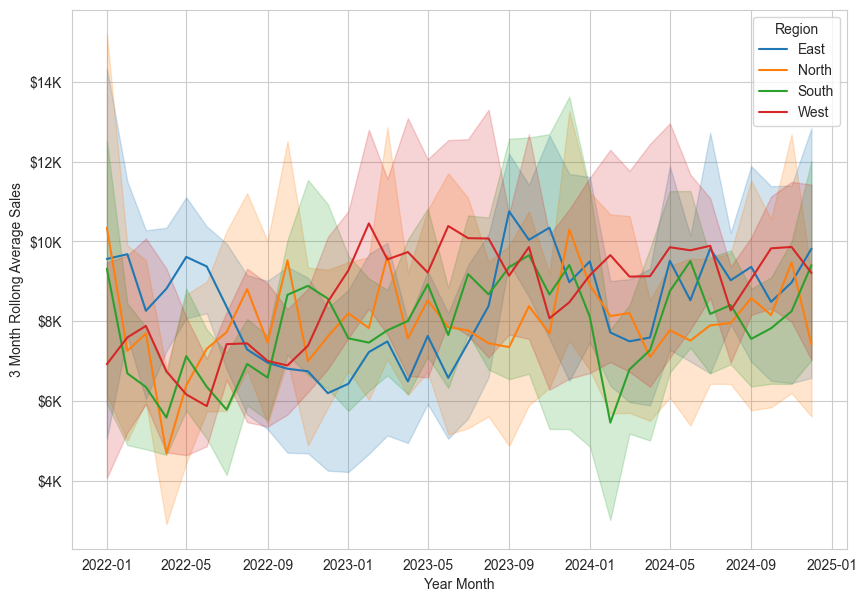

In [25]:
df_temp = df.groupby(
    ['YearMonth','Product Name','Category','Region']
)['Sales'].sum().reset_index()

df_temp = df_temp.sort_values(
    ['Product Name','Category','Region','YearMonth']
)

df_temp['Sales_Rolling_3'] = (
    df_temp
    .groupby(['Product Name','Category','Region'])['Sales']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K')
plt.figure(figsize = (10,7))
sns.lineplot(x = 'YearMonth',y = 'Sales_Rolling_3',data = df_temp,hue = 'Region')
plt.gca().yaxis.set_major_formatter(formatter)
plt.ylabel("3 Month Rollong Average Sales")
plt.xlabel("Year Month")
plt.show()

**Purpose of the chart**

*This chart shows the Region wise sales (3 month moving average).*

**Insights**

- *Since Electronics contributes the highest share of revenue across all regions, the early 2022 and early 2024 decline in regional sales appears to be largely influenced by the drop in Electronics performance, along with softness in other categories.*
- *West is the strongest and stable market with stable sales as compared to east,north and south.*
- *South is the most volatile market(highest dip in sales in early 2024) with unpredictable Sales and Profit Trend.*
- *East is stable and with moderate growth, with clear recovery and upward trend through 2023 to 2024.*
- *Regional dips align with category-level slowdowns, especially Electronics.*

**Business Strategies**

- West Region: Scale Agressively
    - Increase inventory availability.
    - Pilot new product launches in West first.
    - Increase digital marketing Spend.
- South Region: Reduce Volatility
    - Reduce inventory risk (lean stock model)
    - Run Stable subscription/Bulk deals.
- North Region and Eastern Region: Stimulate growth
    - Targeted regional promotions.
    - Improve distribution logistics.

**Chart - 8**

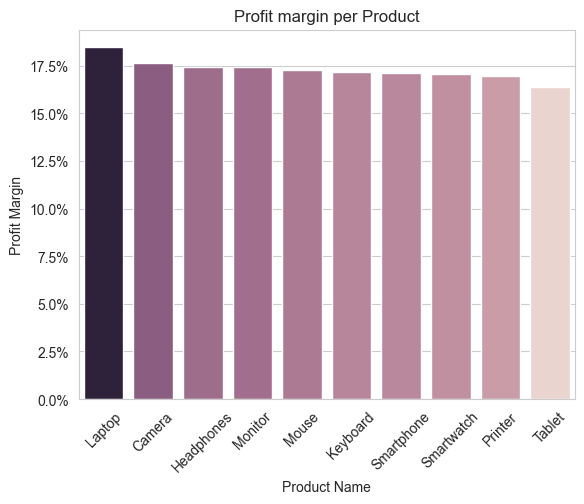

In [26]:
profit_margin = df.groupby(['Product Name'])[['Sales','Profit']].sum().reset_index()
profit_margin['Profit_Margin'] = (profit_margin['Profit']/profit_margin['Sales'])*100
profit_margin = profit_margin.sort_values(by = 'Profit_Margin',ascending=False)

plt.title("Profit margin per Product")
sns.barplot(x = 'Product Name',y = 'Profit_Margin', data = profit_margin,hue = 'Profit_Margin',legend = False)
formatter = ticker.FuncFormatter(lambda x, pos: f'{x}%')
plt.gca().yaxis.set_major_formatter(formatter)
plt.xticks(rotation=45)
plt.ylabel("Profit Margin")
plt.show()

**Purpose of the chart**

*This bar chart shows the Profit margin comparison of each product.*

**Insights**

- *All products profit margin is between 15.0% to 17%, Laptop has slightly more Profit margin (> 17.5%) than other products.*
- *Tablet has lowest profit margin among all products.*

**Business Strategies**

1. *Push high-margin products in strong regions.*
    - *Focus laptop and Camera sales in East & West Region.*
2. *Avoid Heavy discounts on Tablets.*
3. *Bundle Strategies*
    - *Pair High Margin (Laptop) with Moderate margin accessories.*

**Chart - 9**

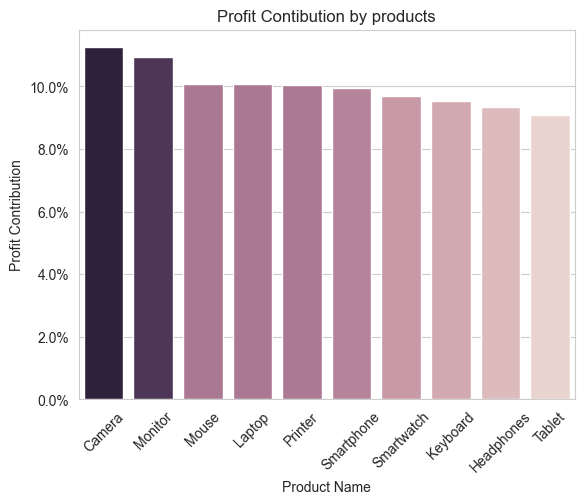

In [27]:
# Profit contribution by products
profit_contribution = df.groupby('Product Name')['Profit'].sum().reset_index()
total_profit = profit_contribution['Profit'].sum()
profit_contribution['contribution_%'] = (profit_contribution['Profit']/total_profit)*100
profit_contribution = profit_contribution.sort_values(by = 'contribution_%',ascending = False)

plt.title('Profit Contibution by products')
sns.barplot(x = 'Product Name',y = 'contribution_%',data = profit_contribution,hue = 'contribution_%',legend = False)
formatter = ticker.FuncFormatter(lambda x, pos: f'{x}%')
plt.gca().yaxis.set_major_formatter(formatter)
plt.xticks(rotation=45)
plt.ylabel("Profit Contribution")
plt.show()

**Insights**

1. *Although from chart - 5A its clear that smartwatch has high sales, but it has low profit contribution than Camera and Monitor.*
2. *Profit distribution is fairly balanced.*
3. *No single product dominates total profit.*

**Business Strategy**

- *Scale Profit driving products(Camera and Monitor).*
- *Avoid aggresive discount on highest margin products.*
- *Reevaluate Tablet strategy by:
    - *Improving pricing.*
    - *Reduce Cost.*
    - *Bundle it.*
    - *Deprioritize marketing spend.*

**Chart - 9B**

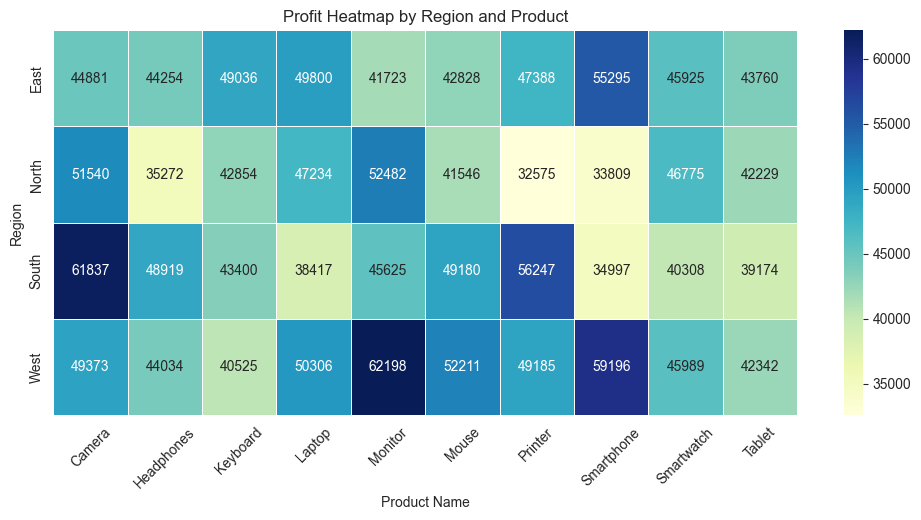

In [28]:
# Product performance in each region.
df_temp = df.groupby(['Region','Product Name'])['Profit'].sum().reset_index()
heatmap_data = df_temp.pivot(index='Region', columns='Product Name', values='Profit')
heatmap_data
plt.figure(figsize=(12,5))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt=".0f", 
            cmap="YlGnBu",
            linewidths=0.5)

plt.title("Profit Heatmap by Region and Product")
plt.xticks(rotation=45)
plt.show()

**Insights**

- *West is the strongest and most diversified profit region, driven particularly by Monitor and Smartphone.*
- *South shows strong but product-specific performance, especially in Camera and Printer.*
- *East provides balanced and stable contributions (No extreme highs & lows across Products).*
- *North demonstrates the highest volatility (with fewer profit from Headphones, Printer & Smartphone).*
- *Monitor emerges as the most consistent high-profit product across regions, whereas Tablet remains the weakest contributor.*
- ***Business Risk Areas***
    - ***West Region***
        - *Key Concentration risk in Monitor heavy profits.*
    - ***South Region***
        - *Key Concentration risk in Camera & Printer heavy profits.*
    - ***North Region***
        - *Highly eneven demad pattern.*

**Business Strategy**

***West Region – Protect & Diversify***
Strategy:
1. *Diversify Profit Base*
    - *Push Smartphone, Laptop, and Mouse alongside Monitor.*
    - *Create bundled offers (Monitor + Laptop / Monitor + Accessories).*
2. *Premium Positioning*
    - *Maintain premium pricing for Monitor.*
    - *Launch upgraded versions here first.*
3. *Risk Control*
    - *Avoid over-allocation of inventory only to Monitor.*
    - *Expand share of other high-margin products.*

***South Region – Balance Product Mix***
Strategy:
1. *Cross-Sell Strategy*
    - Bundle Camera with Laptop or Smartphone.
    - Offer Printer + accessory discounts.

2. Grow Underpenetrated Products
    - Increase marketing for Smartphone and Monitor.
    - Study why these products underperform in South.

3. Stabilize Revenue
    - Introduce mid-range products to reduce extreme swings.
  
***North Region – Stabilize Demand***
Strategy:

1. Diagnose Pricing & Demand
    - Conduct pricing sensitivity analysis.
    - Check competitive landscape.

2. Targeted Promotions
    - Limited-time offers for weak categories.
    - Improve retailer incentives.

3. Improve Forecasting
    - Strengthen demand planning.
    - Avoid stock-outs or overstocking.

**East Region – Scale Carefully**
Strategy:
- Gradually increase marketing investment.
- Test premium product launches.
- Use East as controlled growth region.

# **Conclusion**

**Revenue Structure**
1. *Electronics is the primary revenue driver across all regions.*
2. *Regional dips in 2022 and 2024 align with slowdowns in Electronics and other categories.*
3. *Revenue Performance is strongly influenced by category level especially Electronics.*

**Regional Performance**
1. *West is the strongest region with most diversified profit region and stable sales performance.*
2. *East is stable and improving.*
3. *North shows inconsistency, with irregular spikes and dips because of uneven demand pattern.*
4. *South shows volatility, with sharp spikes and dips because of high product dependency on profit (Camera & Printer).*

**Profitability Insights**
1. *Laptop has the highest profit margin, but its not high profit contributing.*
2. *Camera and Monitor are the most profit contributing.*
3. *Tablet is Lowest profit contributing item.*
4. *Profit distribution across the products is fairly balanced.*
5. *Volume drives profitability more than margin alone.*

# **Recommendation**

*The company should defend its stronghold in West while gradually diversifying regional contribution to reduce concentration risk. Revenue dependency on Electronics must be mitigated through product and category expansion. North requires operational stabilization, and South needs product mix rebalancing. Given that profitability is volume-driven, strategic focus should prioritize scaling high-demand products rather than solely improving margins.*